In [ ]:
from google.colab import files
uploaded = files.upload()   # this opens a file picker — select both CSVs

Saving review_clean.json to review_clean.json
Saving playstore_clean.json to playstore_clean.json


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_json('playstore_clean.json')
reviews = pd.read_json('review_clean.json')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.columns.tolist())

(10357, 13)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

   Reviews  Size_MB  Installs  Type  Price Content Rating  \
0      159     19.0     10000  Free    0.0       Everyone   
1      967     14.0    500000  Free    0.0       Everyone   
2    87510      8.7   5000000  Free    0.0       Everyone   
3   215644     25.0  50000000  Free    0.0           Teen   
4      967      2.8    100000  Free    0.0       Everyone   

                      Genres Last_Updated         Current Ver   Android Ver  
0               Art & Design   2018-01-07               1.0.0 

## **Step 2: Data Validation Check**

In [ ]:
# Ensure Last_Updated is a real datetime, extract year for trend analysis
df['Last_Updated'] = pd.to_datetime(df['Last_Updated'], errors='coerce')
df['Update_Year'] = df['Last_Updated'].dt.year

print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate app names:", df['App'].duplicated().sum())
print("\nUpdate year range:", df['Update_Year'].min(), "-", df['Update_Year'].max())

Missing values per column:
App                  0
Category             0
Rating            1465
Reviews              0
Size_MB           1526
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last_Updated         0
Current Ver          0
Android Ver          0
Update_Year          0
dtype: int64

Duplicate app names: 698

Update year range: 2010 - 2018


## **Step 3: KPI Summary (matches your dashboard's top cards)**

In [ ]:
total_apps = df['App'].nunique()
total_installs = df['Installs'].sum()
avg_rating = df['Rating'].mean()

print(f"Total Apps: {total_apps:,}")
print(f"Total Installs: {total_installs:,}")
print(f"Average Rating: {avg_rating:.2f}")

Total Apps: 9,659
Total Installs: 146,631,914,527
Average Rating: 4.19


## **Step 4: Top 10 Categories by Installs**

/tmp/ipykernel_3123/4259286884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="Blues_r")


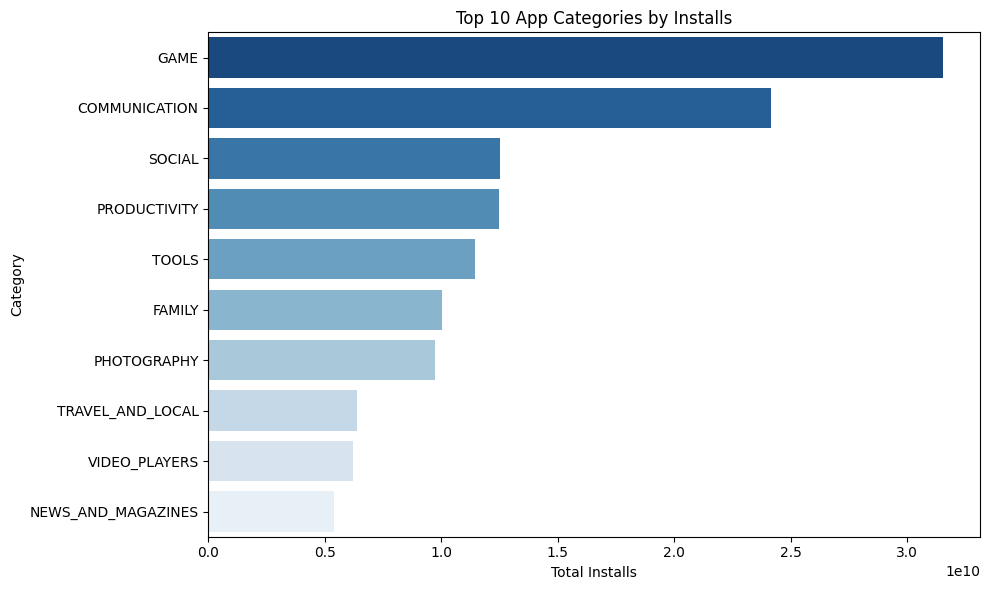

In [ ]:
top_categories = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="Blues_r")
plt.xlabel("Total Installs")
plt.title("Top 10 App Categories by Installs")
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()

## **Step 5: Installs Trend Over Time**

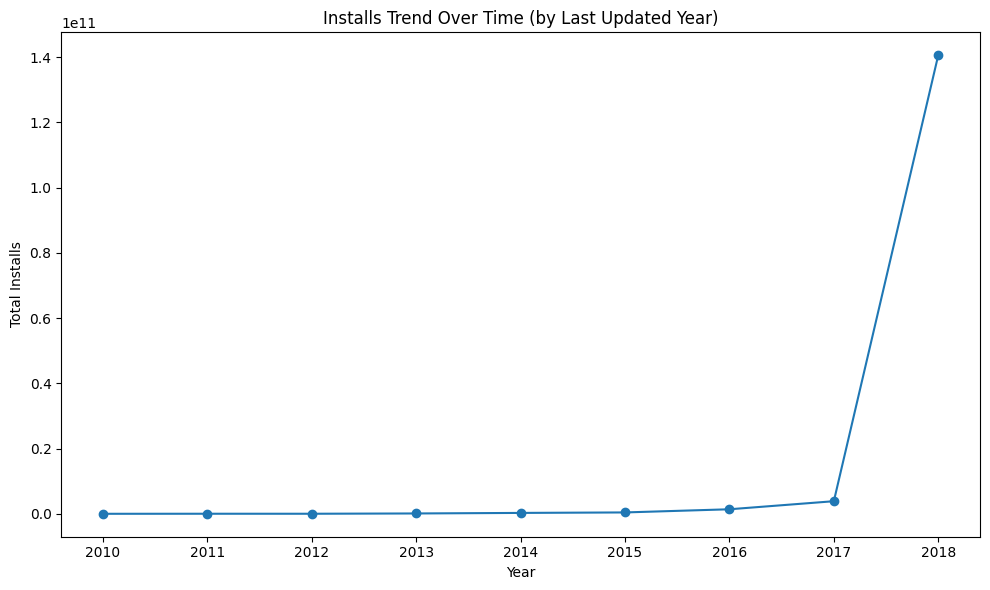

In [ ]:
trend = df.dropna(subset=['Update_Year']).groupby('Update_Year')['Installs'].sum()

plt.figure(figsize=(10,6))
plt.plot(trend.index, trend.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Total Installs")
plt.title("Installs Trend Over Time (by Last Updated Year)")
plt.tight_layout()
plt.savefig('installs_trend.png', dpi=150)
plt.show()

## **Step 6: App Type Distribution (Free vs Paid)**

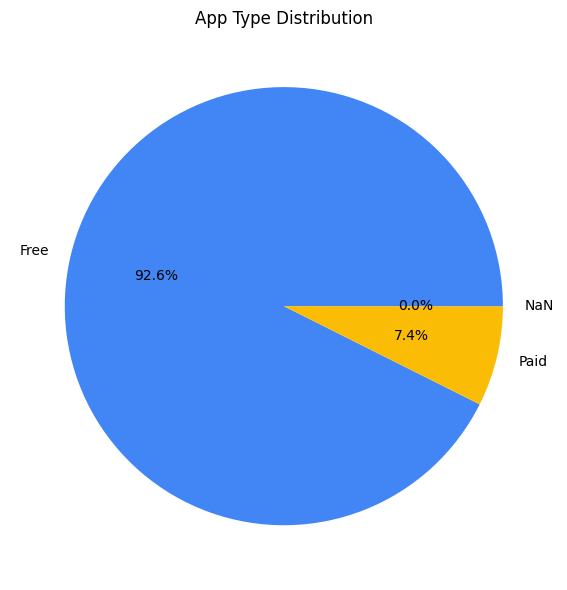

In [ ]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#4285F4', '#FBBC05'])
plt.title("App Type Distribution")
plt.tight_layout()
plt.savefig('type_distribution.png', dpi=150)
plt.show()

## **Step 7: Ratings vs Installs (with correlation stat — key differentiator)**

Correlation (Rating vs log10-Installs): r = 0.114, p-value = 0.0000


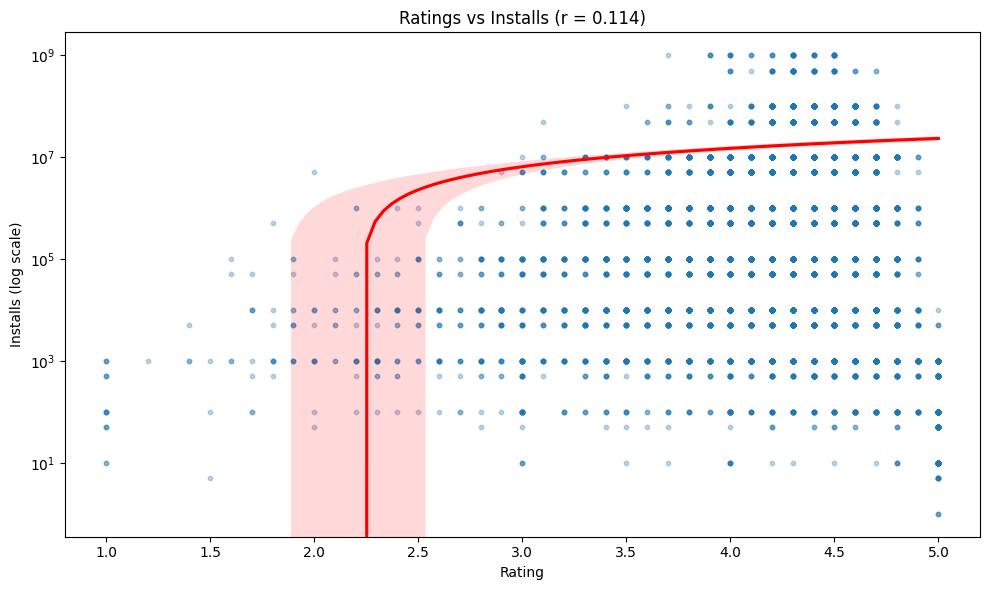

In [ ]:
valid = df.dropna(subset=['Rating', 'Installs'])
valid = valid[valid['Installs'] > 0]

corr, p_value = stats.pearsonr(valid['Rating'], np.log10(valid['Installs']))
print(f"Correlation (Rating vs log10-Installs): r = {corr:.3f}, p-value = {p_value:.4f}")

plt.figure(figsize=(10,6))
sns.regplot(x='Rating', y='Installs', data=valid, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.yscale('log')
plt.xlabel("Rating")
plt.ylabel("Installs (log scale)")
plt.title(f"Ratings vs Installs (r = {corr:.3f})")
plt.tight_layout()
plt.savefig('ratings_vs_installs.png', dpi=150)
plt.show()

## **Step 8: Top Paid Apps by Rating**

/tmp/ipykernel_3123/1892518502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='App', data=top_paid, palette="Greens_r")


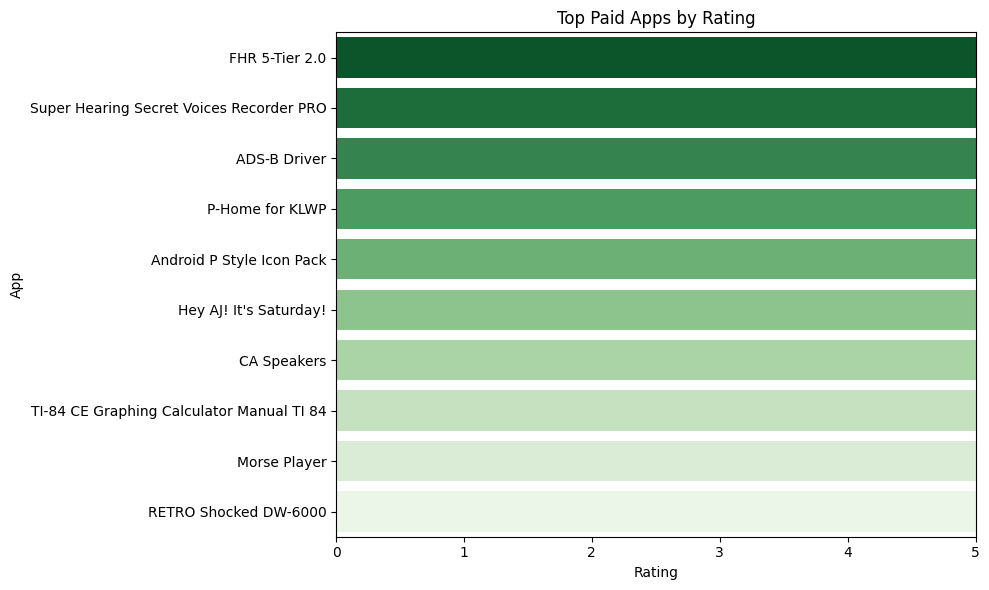

                                            App             Category  Rating  \
2013                             FHR 5-Tier 2.0              MEDICAL     5.0   
2004   Super Hearing Secret Voices Recorder PRO              MEDICAL     5.0   
3512                               ADS-B Driver                TOOLS     5.0   
3997                            P-Home for KLWP      PERSONALIZATION     5.0   
4022                  Android P Style Icon Pack      PERSONALIZATION     5.0   
4781                     Hey AJ! It's Saturday!  BOOKS_AND_REFERENCE     5.0   
6631                                CA Speakers            LIFESTYLE     5.0   
6735  TI-84 CE Graphing Calculator Manual TI 84               FAMILY     5.0   
7543                               Morse Player               FAMILY     5.0   
8529                      RETRO Shocked DW-6000      PERSONALIZATION     5.0   

      Price  Installs  
2013   2.99       500  
2004   2.99       100  
3512   1.99       100  
3997   0.99       100  

In [ ]:
top_paid = df[df['Type'] == 'Paid'].dropna(subset=['Rating']).sort_values(
    ['Rating', 'Installs'], ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Rating', y='App', data=top_paid, palette="Greens_r")
plt.xlim(0, 5)
plt.title("Top Paid Apps by Rating")
plt.tight_layout()
plt.savefig('top_paid_apps.png', dpi=150)
plt.show()

print(top_paid[['App', 'Category', 'Rating', 'Price', 'Installs']])

## **Step 9: Does App Size affect Installs? (correlation check)**

In [ ]:
size_valid = df.dropna(subset=['Size_MB', 'Installs'])
corr_size, p_size = stats.pearsonr(size_valid['Size_MB'], np.log10(size_valid['Installs'] + 1))
print(f"Correlation (Size_MB vs log10-Installs): r = {corr_size:.3f}, p-value = {p_size:.4f}")

Correlation (Size_MB vs log10-Installs): r = 0.334, p-value = 0.0000


## **Step 10: Sentiment Analysis by Category (merges playstore + reviews)**

Sentiment           Pct_Positive
Category                        
COMICS                 87.804878
AUTO_AND_VEHICLES      81.660900
EVENTS                 79.113924
EDUCATION              78.295255
HEALTH_AND_FITNESS     76.183795
FOOD_AND_DRINK         74.058577
LIBRARIES_AND_DEMO     71.471471
PARENTING              71.153846
WEATHER                70.815451
MEDICAL                70.353698


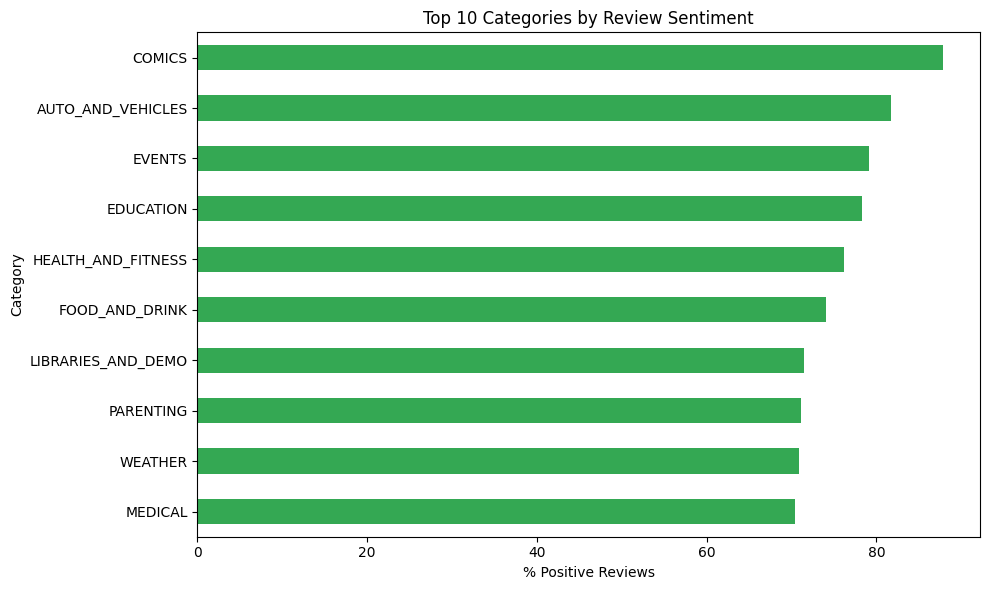

In [ ]:
merged = reviews.merge(df[['App', 'Category']], on='App', how='inner')

sentiment_by_cat = merged.groupby('Category')['Sentiment'].value_counts(normalize=True).unstack().fillna(0)
sentiment_by_cat['Pct_Positive'] = sentiment_by_cat.get('Positive', 0) * 100
sentiment_by_cat = sentiment_by_cat.sort_values('Pct_Positive', ascending=False)

print(sentiment_by_cat[['Pct_Positive']].head(10))

plt.figure(figsize=(10,6))
sentiment_by_cat['Pct_Positive'].head(10).plot(kind='barh', color='#34A853')
plt.xlabel("% Positive Reviews")
plt.title("Top 10 Categories by Review Sentiment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('sentiment_by_category.png', dpi=150)
plt.show()

# **A/B Testing and Hypothesis Testing**

## **Step 11: A/B Testing / Hypothesis Test 1 — Recently Updated vs Older Apps**

In [ ]:
from scipy import stats
import numpy as np

# Split: apps updated in 2018 (most recent year in dataset) vs before
recent = df[df['Update_Year'] == 2018]['Installs'].dropna()
older = df[df['Update_Year'] < 2018]['Installs'].dropna()

print(f"Recent apps (n={len(recent)}): mean installs = {recent.mean():,.0f}")
print(f"Older apps (n={len(older)}): mean installs = {older.mean():,.0f}")

# Log-transform since install counts are heavily right-skewed
t_stat, p_val = stats.ttest_ind(np.log10(recent + 1), np.log10(older + 1), equal_var=False)
print(f"\nWelch's t-test: t = {t_stat:.3f}, p-value = {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print(f"Result: Statistically significant (p < {alpha}). Reject the null hypothesis.")
    print("Conclusion: Apps updated more recently have significantly different install counts.")
else:
    print(f"Result: Not statistically significant (p >= {alpha}). Fail to reject the null hypothesis.")

Recent apps (n=6934): mean installs = 20,271,903
Older apps (n=3423): mean installs = 1,772,287

Welch's t-test: t = 28.647, p-value = 0.000000
Result: Statistically significant (p < 0.05). Reject the null hypothesis.
Conclusion: Apps updated more recently have significantly different install counts.


## **Step 12: A/B Testing / Hypothesis Test 2 — Free vs Paid Installs**

In [ ]:
free = df[df['Type'] == 'Free']['Installs'].dropna()
paid = df[df['Type'] == 'Paid']['Installs'].dropna()

print(f"Free apps (n={len(free)}): mean installs = {free.mean():,.0f}")
print(f"Paid apps (n={len(paid)}): mean installs = {paid.mean():,.0f}")

t_stat2, p_val2 = stats.ttest_ind(np.log10(free + 1), np.log10(paid + 1), equal_var=False)
print(f"\nWelch's t-test: t = {t_stat2:.3f}, p-value = {p_val2:.6f}")

if p_val2 < alpha:
    print(f"Result: Statistically significant (p < {alpha}). Reject the null hypothesis.")
    print("Conclusion: Free and Paid apps have significantly different install counts.")
else:
    print(f"Result: Not statistically significant (p >= {alpha}). Fail to reject the null hypothesis.")

Free apps (n=9591): mean installs = 15,281,273
Paid apps (n=765): mean installs = 90,491

Welch's t-test: t = 32.040, p-value = 0.000000
Result: Statistically significant (p < 0.05). Reject the null hypothesis.
Conclusion: Free and Paid apps have significantly different install counts.


## **Step 13: Visualize both comparisons**

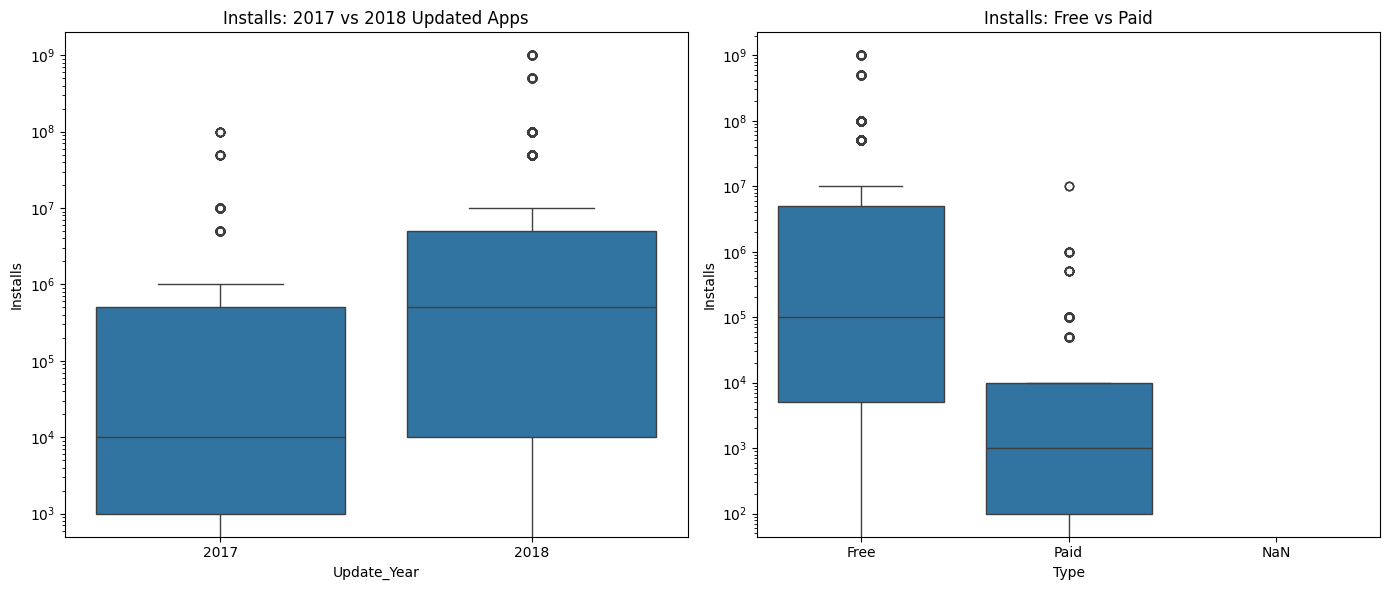

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_plot1 = df[df['Update_Year'].isin([2017, 2018])].dropna(subset=['Installs'])
sns.boxplot(x='Update_Year', y='Installs', data=df_plot1, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Installs: 2017 vs 2018 Updated Apps')

sns.boxplot(x='Type', y='Installs', data=df.dropna(subset=['Installs']), ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Installs: Free vs Paid')

plt.tight_layout()
plt.savefig('ab_test_comparison.png', dpi=150)
plt.show()

## **Rechecking dataset and files for Tableau**

In [ ]:
print(df.shape)

(10357, 14)


In [ ]:
df.to_csv('playstore_for_tableau.csv', index=False)
files.download('playstore_for_tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Export sentiment-by-category summary for Tableau
merged = reviews.merge(df[['App', 'Category']], on='App', how='inner')
sentiment_summary = merged.groupby('Category')['Sentiment'].value_counts(normalize=True).unstack().fillna(0)
sentiment_summary['Pct_Positive'] = (sentiment_summary.get('Positive', 0) * 100).round(1)
sentiment_summary = sentiment_summary.reset_index()[['Category', 'Pct_Positive']]
sentiment_summary = sentiment_summary.sort_values('Pct_Positive', ascending=False)

sentiment_summary.to_csv('sentiment_by_category.csv', index=False)
files.download('sentiment_by_category.csv')

print(sentiment_summary)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sentiment             Category  Pct_Positive
5                       COMICS          87.8
1            AUTO_AND_VEHICLES          81.7
10                      EVENTS          79.1
8                    EDUCATION          78.3
15          HEALTH_AND_FITNESS          76.2
13              FOOD_AND_DRINK          74.1
17          LIBRARIES_AND_DEMO          71.5
22                   PARENTING          71.2
32                     WEATHER          70.8
20                     MEDICAL          70.4
24                 PHOTOGRAPHY          69.0
23             PERSONALIZATION          68.1
25                PRODUCTIVITY          67.9
0               ART_AND_DESIGN          67.8
19         MAPS_AND_NAVIGATION          67.2
6                COMMUNICATION          67.0
3          BOOKS_AND_REFERENCE          66.9
26                    SHOPPING          66.5
11                      FAMILY          65.6
12                     FINANCE          64.8
18                   LIFESTYLE          64.2
9         